# Analyse des résultats 

In [1]:
import pandas as pd

In [2]:
def merge_type(res):
    """
    Merge les résultats avec le dictionnaire pour ajouter les colonnes TYPE et TYPE2.
    entrée:
        res : df contenant les résultats avec une colonne 'SYMBOL' (les tickers).
    Return:
        df fusionné avec les colonnes 'TYPE' et 'TYPE2' ajoutées.
    """
    dict_bbg = pd.read_excel('C:\\Users\\diane\\time-series-pred\\Datasets\\230210 Factor Set - Dictionnary (bbg only).xlsx')
    df_final = pd.merge(res, dict_bbg[['SYMBOL', 'TYPE', 'TYPE2']], on='SYMBOL', how='left')
    cols = ['SYMBOL', 'TYPE', 'TYPE2'] + [c for c in res.columns if c != 'SYMBOL']
    df_final['TYPE2'] = df_final['TYPE'].astype(str) + " - " + df_final['TYPE2'].astype(str)
    df_final = df_final[cols]
    return df_final

### Analyse AR(1)

In [3]:
res_ar = pd.read_csv('Resultats/resultats_all_tickers_AR(1).csv')

In [4]:
df_ar = merge_type(res_ar)
df_ar.head()

,SYMBOL,TYPE,TYPE2,MSE,OLS_R2,OLS_Intercept,OLS_Slope,OLS_P_Value_Intercept,P_Value_Slope
0,ADBF Index,Stock Market,Stock Market - Financials,0.000261,0.005777,0.000271,0.497567,0.350072,4.184202e-05
1,ADCM Index,Stock Market,Stock Market - Services,0.000528,0.006266,0.000580,0.388187,0.170883,3.824884e-05
2,ADCT Index,Stock Market,Stock Market - Industrials,0.000304,0.017216,0.000094,0.663209,0.753838,1.307078e-12
3,ADEG Index,Stock Market,Stock Market - Energy,0.000757,0.003857,-0.000040,0.456944,0.932014,1.244449e-03
4,ADHC Index,Stock Market,Stock Market - Health Care,0.000974,0.000828,-0.000178,0.178875,0.897489,5.209936e-01


In [5]:
def stats_par_type(df_final):
    df_final['is_significant'] = df_final['P_Value_Slope'] < 0.05

    stats_by_type = df_final.groupby('TYPE').agg({
        'P_Value_Slope': ['mean', 'std', 'min', 'max'], 
        'MSE': ['mean', 'std'],                         
        'OLS_R2': ['mean', 'median'],                   
        'OLS_Slope': 'mean',                            
        'is_significant': 'sum'                        
    }).rename(columns={'sum': 'count_significant'
                       }).sort_values(by=('P_Value_Slope', 'mean'))

    stats_by_type2 = df_final.groupby('TYPE2').agg({
        'MSE': 'mean',
        'OLS_R2': 'mean',
        'OLS_Slope': 'mean',
        'P_Value_Slope': 'mean'
    }).sort_values(by=('P_Value_Slope'))

    return stats_by_type, stats_by_type2

In [6]:
stats_type_ar, stats_type2_ar = stats_par_type(df_ar)

print("Stats par type:")
print(display(stats_type_ar.head()))

print("\nStats par type2 (secteurs plus précis):")
print(display(stats_type2_ar.head()))

significance_rate = stats_type_ar[('is_significant', 'count_significant')] / df_ar.groupby('TYPE').size()
print("\nRatio de significativité par type:")
print(significance_rate.sort_values(ascending=False))

Stats par type:


P_Value_Slope                                          \
                          mean       std            min            max   
TYPE                                                                     
Volatility       3.929919e-168  0.000000   0.000000e+00  2.750944e-167   
Real estate       1.502443e-02  0.045045   1.840678e-48   1.351445e-01   
Hedge Funds       6.740519e-02  0.116566   8.316800e-05   2.020040e-01   
Money Market      8.979813e-02  0.190402   0.000000e+00   8.443086e-01   
Corporate Bonds   1.286786e-01  0.285105  7.880041e-260   8.696342e-01   

                      MSE              OLS_R2           OLS_Slope  \
                     mean       std      mean    median      mean   
TYPE                                                                
Volatility       0.043291  0.033013  0.522683  0.362892  0.970629   
Real estate      0.000312  0.000194  0.017979  0.026585  0.551130   
Hedge Funds      0.000025  0.000007  0.002135  0.002237  0.163686   
Money Market     0.001133  0.003440  0.031444  0.007986  0.464747   
Corporate Bonds  0.000045  0.000110  0.030456  0.006321  0.461260   

                   is_significant  
                count_significant  
TYPE                               
Volatility                      7  
Real estate                     8  
Hedge Funds                     2  
Money Market                   40  
Corporate Bonds                21

None

Stats par type2 (secteurs plus précis):


,MSE,OLS_R2,OLS_Slope,P_Value_Slope
TYPE2,,,,
Volatility - -,0.043291,0.522683,0.970629,3.929919e-168
Equity Factors - Size,0.000131,0.009925,0.531553,1.968415e-04
Real estate - -,0.000312,0.017979,0.551130,1.502443e-02
Hedge Funds - -,0.000025,0.002135,0.163686,6.740519e-02
Money Market - Overnight,0.002460,0.029780,0.563992,7.131833e-02


None

Ratio de significativité par type:
TYPE
Volatility         1.000000
Real estate        0.888889
Corporate Bonds    0.807692
Money Market       0.727273
Hedge Funds        0.666667
Sovereign Bonds    0.615385
Equity Factors     0.585366
Stock Market       0.485938
Currency           0.453704
Commodity          0.405063
dtype: float64


## AR(1) (ret) 
juste pour voir si c'est les même

In [7]:
ret_ar_ret = pd.read_csv('Resultats/resultats_all_tickers_AR(1)_ret.csv')

df_ar_ret = merge_type(res_ar)
df_ar_ret.head()

stats_type_ar, stats_type2_ar = stats_par_type(df_ar_ret)

print("Stats par type:")
print(display(stats_type_ar.head()))

print("\nStats par type2 (secteurs plus précis):")
print(display(stats_type2_ar.head()))

significance_rate = stats_type_ar[('is_significant', 'count_significant')] / df_ar_ret.groupby('TYPE').size()
print("\nRatio de significativité par type:")
print(significance_rate.sort_values(ascending=False))

Stats par type:


P_Value_Slope                                          \
                          mean       std            min            max   
TYPE                                                                     
Volatility       3.929919e-168  0.000000   0.000000e+00  2.750944e-167   
Real estate       1.502443e-02  0.045045   1.840678e-48   1.351445e-01   
Hedge Funds       6.740519e-02  0.116566   8.316800e-05   2.020040e-01   
Money Market      8.979813e-02  0.190402   0.000000e+00   8.443086e-01   
Corporate Bonds   1.286786e-01  0.285105  7.880041e-260   8.696342e-01   

                      MSE              OLS_R2           OLS_Slope  \
                     mean       std      mean    median      mean   
TYPE                                                                
Volatility       0.043291  0.033013  0.522683  0.362892  0.970629   
Real estate      0.000312  0.000194  0.017979  0.026585  0.551130   
Hedge Funds      0.000025  0.000007  0.002135  0.002237  0.163686   
Money Market     0.001133  0.003440  0.031444  0.007986  0.464747   
Corporate Bonds  0.000045  0.000110  0.030456  0.006321  0.461260   

                   is_significant  
                count_significant  
TYPE                               
Volatility                      7  
Real estate                     8  
Hedge Funds                     2  
Money Market                   40  
Corporate Bonds                21

None

Stats par type2 (secteurs plus précis):


,MSE,OLS_R2,OLS_Slope,P_Value_Slope
TYPE2,,,,
Volatility - -,0.043291,0.522683,0.970629,3.929919e-168
Equity Factors - Size,0.000131,0.009925,0.531553,1.968415e-04
Real estate - -,0.000312,0.017979,0.551130,1.502443e-02
Hedge Funds - -,0.000025,0.002135,0.163686,6.740519e-02
Money Market - Overnight,0.002460,0.029780,0.563992,7.131833e-02


None

Ratio de significativité par type:
TYPE
Volatility         1.000000
Real estate        0.888889
Corporate Bonds    0.807692
Money Market       0.727273
Hedge Funds        0.666667
Sovereign Bonds    0.615385
Equity Factors     0.585366
Stock Market       0.485938
Currency           0.453704
Commodity          0.405063
dtype: float64


## Tableau et figures pour le papier

GLOBAL LEADERBOARD
                                  MSE    OLS_R2  OLS_Slope  \
Model                                                        
SVM                      4.205067e-04  0.035266   0.339527   
LGBM                     3.894985e-04  0.049722   0.553130   
AR(2)                    3.811157e-03  0.013980   0.286017   
AR(5)                    8.751065e-03  0.011883   0.203959   
GRU_Stacked_seq8         1.275514e-03  0.005587   0.137990   
AR(10)                   6.282651e-02  0.009633   0.140567   
AR(1)                    2.096471e-03  0.011826   0.130874   
MA(10)                   9.541426e-03  0.005394  -0.211178   
ARMA(5,5)                5.639310e+07  0.005364   0.262430   
ARMA(2,2)                1.021322e+15  0.005848   0.493472   
MA(5)                    9.223175e-03  0.005570   0.457584   
MA(2)                    9.022259e-03  0.005800   2.339970   
SARIMA(1,0,1)(1,0,1)_21  9.708147e-03  0.005328  -0.871884   
SARIMA(1,0,1)(1,0,1)_5   1.020709e-02  0.005137  -2

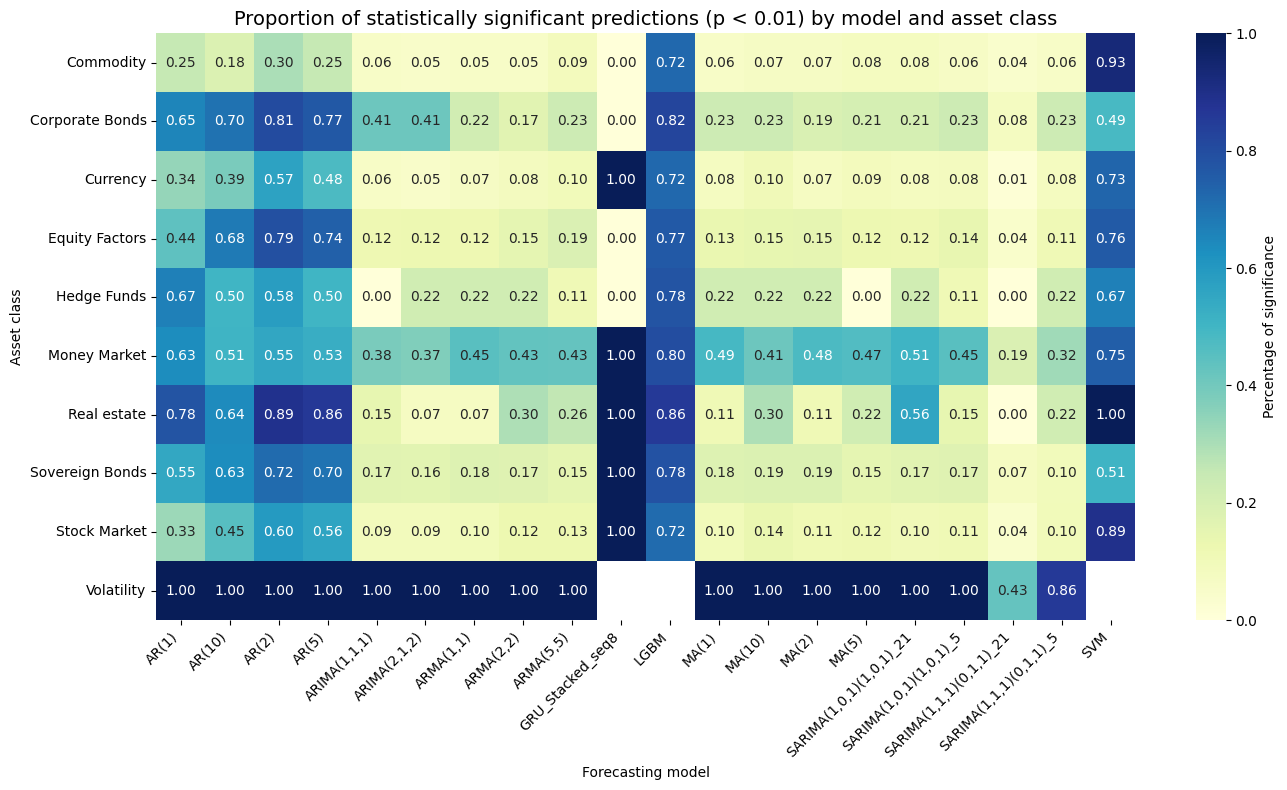

In [3]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

def load_and_merge_all_results(results_dir, dict_path):
    """
    Charge tous les CSV de résultats, extrait le nom du modèle, 
    et fusionne avec le dictionnaire des classes d'actifs.
    """
    dict_bbg = pd.read_excel(dict_path)
    
    all_data = []
    
    for file in os.listdir(results_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(results_dir, file)
            df_temp = pd.read_csv(file_path)
            
            model_name = file.replace('resultats_all_tickers_', '') \
                             .replace('resultats_test_tickers_', '') \
                             .replace('_all_tickers', '') \
                             .replace('.csv', '') \
                             .replace('resultats_', '') \
                             .replace('_f5years', '') \
                             .replace('_f1month', '') \
                             .replace('_f5ans', '') \
                             .replace('_f1year', '')
            df_temp['Model'] = model_name
            all_data.append(df_temp)
            
    df_all = pd.concat(all_data, ignore_index=True)
    df_final = pd.merge(df_all, dict_bbg[['SYMBOL', 'TYPE', 'TYPE2']], on='SYMBOL', how='left')
    
    df_final['is_significant'] = df_final['P_Value_Slope'] < 0.01
    
    return df_final

def generate_paper_tables(df_final):
    print("GLOBAL LEADERBOARD")
    global_summary = df_final.groupby('Model').agg({
        'MSE': 'mean',
        'OLS_R2': 'mean',
        'OLS_Slope': 'mean',
        'is_significant': 'mean'
    }).rename(columns={'is_significant': 'Percentage of significance'}).sort_values(by='Percentage of significance', ascending=False)
    
    print(global_summary)
    print("\n")
    
    print("SIGNIFICANCE RATIO BY ASSET CLASS (HEATMAP DATA)")
    pivot_sig = df_final.pivot_table(
        index='TYPE', 
        columns='Model', 
        values='is_significant', 
        aggfunc='mean'
    )
    print(pivot_sig)
    print("\n")
    
    print("R2 MEAN BY ASSET CLASS")
    pivot_r2 = df_final.pivot_table(
        index='TYPE', 
        columns='Model', 
        values='OLS_R2', 
        aggfunc='mean'
    )
    print(pivot_r2)
    
    return global_summary, pivot_sig, pivot_r2

RESULTS_DIR = 'Resultats'
DICT_PATH = 'Datasets/230210 Factor Set - Dictionnary (bbg only).xlsx'

df_master = load_and_merge_all_results(RESULTS_DIR, DICT_PATH)
global_summary, pivot_sig, pivot_r2 = generate_paper_tables(df_master)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_sig, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Percentage of significance'})
plt.title("Proportion of statistically significant predictions (p < 0.01) by model and asset class", fontsize=14)
plt.ylabel("Asset class")
plt.xlabel("Forecasting model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()